## Flow Matching — SSH Gulf Stream (NATL-GF)

Conditional Flow Matching (Heun ODE) applied to SSH data from the Gulf Stream region.
- Data: NATL-GF 5-nadir + SWOT, 0.05° native resolution, resize_factor=2 → 0.1°
- Window: 9 time steps, 128×128 patches

In [23]:
!nvidia-smi

Thu Jun 18 08:36:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   26C    P8             30W /  300W |      17MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_VISIBLE_DEVICES=2


In [25]:
import math
import os
import zipfile
import glob
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import xarray as xr
import pandas as pd
import torch
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torchinfo import summary

import sys
sys.path.append('../..')     # -> consistency/ (flowmatching_models_FM, spectral_utils)
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/ (src)

from flowmatching_models_FM import (
    UNetFM, UNetFMConfig,
    LitFlowMatchingModel, LitFMConfig,
    LogScaleModel,
    heun_sample, euler_sample,
    neglogpdf, neglogcdf,
    sample_uniform_time, masked_average,
)

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed — CRPS disabled.")

## DataModule — SSH Gulf Stream (NATL-GF)

Load altimetry SSH data (5-nadir + SWOT observations), resize_factor=2 for 128×128 patches at ~0.1° resolution.

Norm stats (0.3047108663749711, 0.3879814586804132)
window_size (C) = 9
TrainingItem shapes -- input (y): (9, 128, 128), tgt (x): (9, 128, 128)


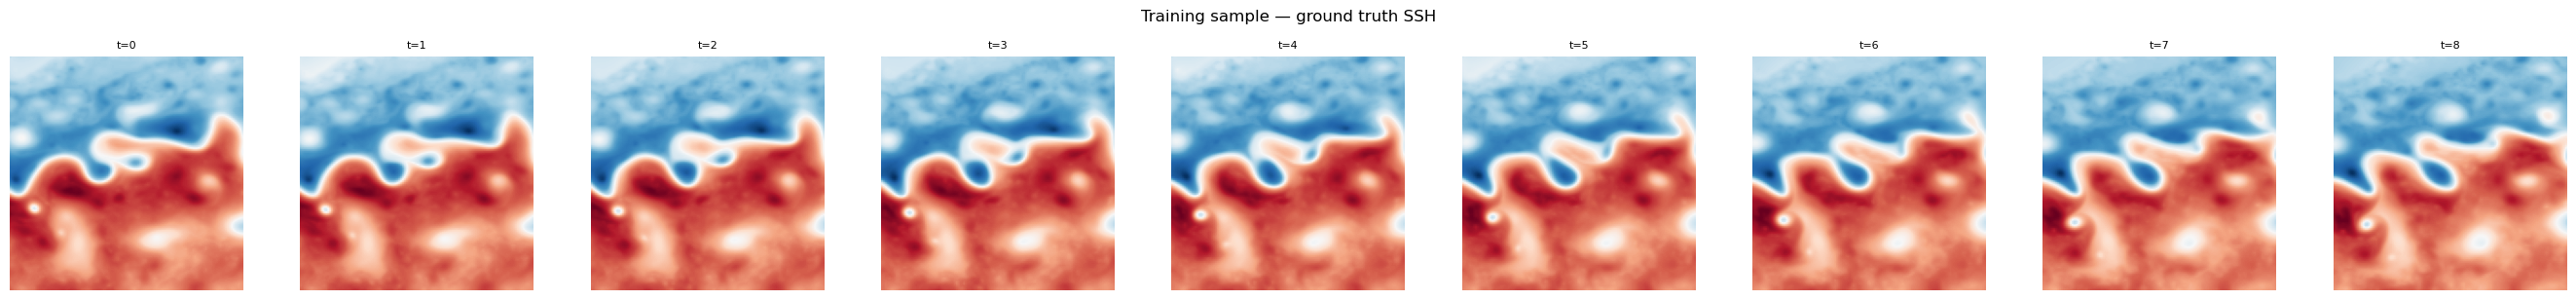

In [26]:
import pyinterp
import pyinterp.fill
import pyinterp.backends.xarray
from collections import namedtuple
from src.data_notebook import BaseDataModule

datadir = "/Odyssey/private/m19beauc/NATL_dataset"

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

def remove_nan(da):
    da["lon"] = da.lon.assign_attrs(units="degrees_east")
    da["lat"] = da.lat.assign_attrs(units="degrees_north")
    da.transpose("lon", "lat", "time")[:, :] = pyinterp.fill.gauss_seidel(
        pyinterp.backends.xarray.Grid3D(da)
    )[1]
    return da

def load_altimetry_data(path):
    ds = (
        xr.open_dataset(path)
        .load()
        .assign(
            input=lambda ds: ds.nadir_obs,
            tgt=lambda ds: remove_nan(ds.ssh),
        )
    )
    return (
        ds[[*TrainingItem._fields]]
        .transpose("time", "lat", "lon")
        .to_array()
    )

lon_min, lon_max = -66.3, -53.5
lat_min, lat_max =  31.7,  44.5

datamodule = BaseDataModule(
    input_da=load_altimetry_data(datadir + "/natl_gf_w_5nadirs_swot.nc"),
    domains={
        'train': {'time': slice('2013-02-24', '2013-09-30')},
        'val':   {'time': slice('2012-12-15', '2013-02-24')},
        'test':  {'time': slice('2012-10-01', '2012-12-20')},
    },
    xrds_kw={
        'patch_dims':    {'time': 9, 'lat': 128, 'lon': 128},
        'strides':       {'time': 1, 'lat': 128, 'lon': 128},
        'domain_limits': dict(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max)),
    },
    dl_kw={'batch_size': 1, 'num_workers': 1},
    grad=False,
    resize_factor=2,
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = sample.tgt.shape[0]
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes -- input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, min(C, 9), figsize=(3 * min(C, 9), 3))
for t_idx, ax in enumerate(axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth SSH", y=1.01)
plt.tight_layout()
plt.show()

### UNetFM — Velocity-prediction network

Input: `(x_t, y_obs, t)` → predicts the velocity field for the ODE flow from noise to clean signal.

In [27]:
C = datamodule.train_ds[0].tgt.shape[0]
cfg = UNetFMConfig(channels=C)
net = UNetFM(cfg)

summary(
    net,
    input_size=(
        (1, C, 128, 128),   # x_t  — noisy interpolant
        (1, C, 128, 128),   # y    — observations (NaN tolerated)
        (1,),               # t    — pseudo-time scalar
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNetFM                                        [1, 9, 128, 128]          --
├─Conv2d: 1-1                                 [1, 64, 128, 128]         15,616
├─TimeEmbedding: 1-2                          [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 64, 128, 128]         --
│    │    └─Sequential: 3-5                   [1, 64, 128, 128]         37,056
│    │    └─Sequential: 3-6                   [1, 64, 1, 1]             8,256
│

### LightningModule — LitFlowMatchingModel

Uses the linear interpolant of Flow Matching: `x_t = (1-t)*noise + t*x_clean`, loss = MSE on velocity.

In [28]:
# LitFlowMatchingModel is fully self-contained in flowmatching_models_FM.py.
help(LitFlowMatchingModel)

Help on class LitFlowMatchingModel in module flowmatching_models_FM:

class LitFlowMatchingModel(pytorch_lightning.core.module.LightningModule)
 |  LitFlowMatchingModel(network: 'UNetFM', config: 'LitFMConfig', n_log_scale_embedding: 'int' = 128) -> 'None'
 |
 |  Flow Matching Lightning module for the SPDE dataset.
 |
 |  Parameters
 |  ----------
 |  network     : ``UNetFM`` (student / live model)
 |  config      : ``LitFMConfig``
 |  n_log_scale_embedding : embedding dim for the ``LogScaleModel``
 |
 |  Method resolution order:
 |      LitFlowMatchingModel
 |      pytorch_lightning.core.module.LightningModule
 |      lightning_fabric.utilities.device_dtype_mixin._DeviceDtypeModuleMixin
 |      pytorch_lightning.core.mixins.hparams_mixin.HyperparametersMixin
 |      pytorch_lightning.core.hooks.ModelHooks
 |      pytorch_lightning.core.hooks.DataHooks
 |      pytorch_lightning.core.hooks.CheckpointHooks
 |      torch.nn.modules.module.Module
 |      builtins.object
 |
 |  Methods defi

## Training

In [29]:
%tensorboard --logdir=logs_FM_ssh_gf --port 6010

UsageError: Line magic function `%tensorboard` not found.


In [ ]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        import zipfile
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last) and is_valid_checkpoint(last):
        print(f"Valid checkpoint: {last}")
        return last
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in p],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for p in all_ckpts:
        if is_valid_checkpoint(p):
            print(f"Valid checkpoint: {p}")
            return p
    print("No valid checkpoint found. Starting from scratch.")
    return None

C = datamodule.train_ds[0].tgt.shape[0]

LOG_DIR     = "logs_FM_ssh_gf"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

RESET_TRAINING = False
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

network  = UNetFM(UNetFMConfig(channels=C))
lit_fm   = LitFlowMatchingModel(
    network=network,
    config=LitFMConfig(lr_scheduler_iters=1000, eval_n_steps=20),
)

trainer = Trainer(
    accelerator="gpu",
    max_epochs=2500,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_fm, datamodule, ckpt_path=resume_ckpt)

ema_net = lit_fm.ema_model.module
ema_net.save_pretrained(MODEL_PATH)
print(f"EMA model saved to: {MODEL_PATH}")

Valid checkpoint: logs_FM_ssh_gf/v1/checkpoints/last.ckpt


Using 16bit Automatic Mixed Precision (AMP)
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning

✅ Val batch cached: tgt=torch.Size([1, 9, 128, 128])


/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

[Epoch 105]  Val RMSE (20 Heun steps, EMA) = 0.1732
[Epoch 106]  Val RMSE (20 Heun steps, EMA) = 0.1794
[Epoch 107]  Val RMSE (20 Heun steps, EMA) = 0.1812
[Epoch 108]  Val RMSE (20 Heun steps, EMA) = 0.1824
[Epoch 109]  Val RMSE (20 Heun steps, EMA) = 0.1783
[Epoch 110]  Val RMSE (20 Heun steps, EMA) = 0.1738
[Epoch 111]  Val RMSE (20 Heun steps, EMA) = 0.1721
[Epoch 112]  Val RMSE (20 Heun steps, EMA) = 0.1754
[Epoch 113]  Val RMSE (20 Heun steps, EMA) = 0.1747
[Epoch 114]  Val RMSE (20 Heun steps, EMA) = 0.1743
[Epoch 115]  Val RMSE (20 Heun steps, EMA) = 0.1710
[Epoch 116]  Val RMSE (20 Heun steps, EMA) = 0.1779
[Epoch 117]  Val RMSE (20 Heun steps, EMA) = 0.1758
[Epoch 118]  Val RMSE (20 Heun steps, EMA) = 0.1742
[Epoch 119]  Val RMSE (20 Heun steps, EMA) = 0.1752
[Epoch 120]  Val RMSE (20 Heun steps, EMA) = 0.1780
[Epoch 121]  Val RMSE (20 Heun steps, EMA) = 0.1730
[Epoch 122]  Val RMSE (20 Heun steps, EMA) = 0.1779
[Epoch 123]  Val RMSE (20 Heun steps, EMA) = 0.1800
[Epoch 124] 

/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


EMA model saved to: logs_FM_ssh_gf/v1/best_model


## Sampling & Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_PATH = os.path.join("logs_FM_ssh_gf", "best_model")

ema_unet = UNetFM.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"EMA UNetFM loaded from {MODEL_PATH}")
print(f"  Params : {sum(p.numel() for p in ema_unet.parameters()):,}")

EMA UNetFM loaded from logs_FM_ssh_gf/v1/best_model
  Params : 32,279,049


### Test Batch

In [ ]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

x_gt  = batch.tgt.to(device=device, dtype=dtype)
y_obs = batch.input.to(device=device, dtype=dtype)

B, C, H, W = x_gt.shape
print(f"Test batch  x_gt:{tuple(x_gt.shape)}  y_obs:{tuple(y_obs.shape)}")

m_norm, s_norm = datamodule.norm_stats()

Global seed set to 42


Test batch  x_gt:(1, 9, 128, 128)  y_obs:(1, 9, 128, 128)


### Ensemble Generation (N_SAMPLES members)

In [ ]:
N_SAMPLES = 10
N_STEPS   = 20   # Heun ODE steps

samples = []

with torch.no_grad():
    for s in range(N_SAMPLES):
        noise = torch.randn_like(x_gt)
        x_pred, _ = heun_sample(ema_unet, noise, y_obs, n_steps=N_STEPS)
        samples.append(x_pred.cpu())
        print(f"  member {s+1}/{N_SAMPLES} done", end="\r")

samples = torch.stack(samples, dim=0)   # (N_SAMPLES, B, C, H, W)
print(f"\nEnsemble tensor: {tuple(samples.shape)}")

ens_mean = samples.mean(0)              # (B, C, H, W)
ens_std  = samples.std(0)               # (B, C, H, W)

_b = 0
ens_mean_1 = ens_mean[_b]   # (C, H, W)
ens_std_1  = ens_std[_b]    # (C, H, W)
ensemble_1 = samples[:, _b] # (N, C, H, W)

  member 10/10 done
Ensemble tensor: (10, 1, 9, 128, 128)


## Metrics — FM vs GT

Evaluation at the **centre of the assimilation window**.

| Metric | Description |
|---|---|
| **Score** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE** | Root Mean Square Error vs GT |
| **sigma_pred** | Std of the ensemble mean |
| **CRPS** | Continuous Ranked Probability Score at observed pixels |
| **lambda_x** | Resolved scale: wavelength where spectral score = 0.5 |

t=4 | sigma(GT)=0.3935 | obs coverage=23.8%

## Metrics @ t=4 -- pixel = 0.1 deg



,Score,RMSE,sigma_GT,sigma_pred,CRPS,lambda_x [deg]
Method,,,,,,
FM (ens. mean),0.879,0.0477,0.3935,0.4154,0.0230,0.95


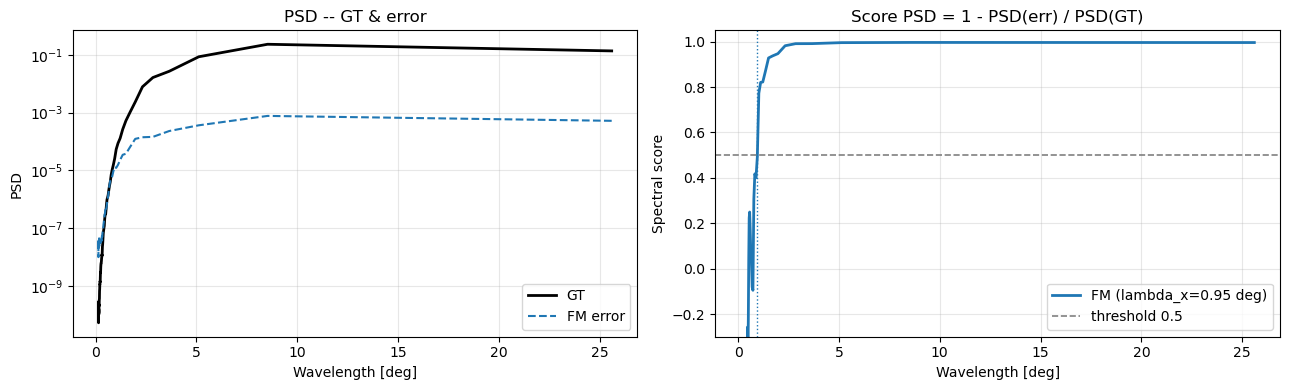

In [ ]:
import sys
sys.path.append('../..')
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

T_EVAL = C // 2
DX = 0.1   # pixel spacing in degrees (0.1° resolution)

gt_n   = batch.tgt[_b, T_EVAL].float().cpu().numpy()
gt_p   = gt_n * s_norm + m_norm

mean_n = ens_mean_1[T_EVAL].float().cpu().numpy()
mean_p = mean_n * s_norm + m_norm

ens_n  = ensemble_1[:, T_EVAL].float().cpu().numpy()
ens_p  = ens_n * s_norm + m_norm

obs_mask = ~np.isnan(batch.input[_b, T_EVAL].float().cpu().numpy())

sigma_gt = float(np.nanstd(gt_p))
print(f't={T_EVAL} | sigma(GT)={sigma_gt:.4f} | obs coverage={obs_mask.mean()*100:.1f}%')

def _metrics_row(pred_p, gt_p, label, ens_p_arr=None, obs_mask=None, dx=DX):
    sigma      = float(np.nanstd(gt_p))
    rmse_v     = float(np.sqrt(np.nanmean((pred_p - gt_p) ** 2)))
    score      = 1.0 - rmse_v / sigma
    sigma_pred = float(np.nanstd(pred_p))
    wl, _, _, spec = psd_spectral_score(pred_p, gt_p, dx=dx)
    lambda_x   = resolved_scale(wl, spec, threshold=0.5)
    crps_val   = np.nan
    if ens_p_arr is not None and HAS_PROPERSCORING and obs_mask is not None:
        obs_ij = np.argwhere(obs_mask)
        if len(obs_ij) > 0:
            crps_val = float(np.mean([
                crps_ensemble(float(gt_p[i, j]), ens_p_arr[:, i, j])
                for i, j in obs_ij
            ]))
    return {
        'Method'    : label,
        'Score'     : f'{score:.3f}',
        'RMSE'      : f'{rmse_v:.4f}',
        'sigma_GT'  : f'{sigma:.4f}',
        'sigma_pred': f'{sigma_pred:.4f}',
        'CRPS'      : f'{crps_val:.4f}' if not np.isnan(crps_val) else '--',
        'lambda_x'  : f'{lambda_x:.2f}' if not np.isnan(lambda_x) else '?',
    }, wl, spec

row_fm, wl_fm, spec_fm = _metrics_row(mean_p, gt_p, 'FM (ens. mean)',
                                       ens_p_arr=ens_p, obs_mask=obs_mask)

df_metrics = pd.DataFrame([row_fm]).set_index('Method')
df_metrics.columns = ['Score','RMSE','sigma_GT','sigma_pred','CRPS','lambda_x [deg]']
print(f'\n## Metrics @ t={T_EVAL} -- pixel = {DX} deg\n')
display(df_metrics)

# ── Spectral plots (PSD error + spectral score) ──────────────────────────────
_, psd_gt_r, psd_err_fm, _ = psd_spectral_score(mean_p, gt_p, dx=DX)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
valid = np.isfinite(wl_fm) & np.isfinite(psd_gt_r) & (psd_gt_r > 0)
ax.semilogy(wl_fm[valid], psd_gt_r[valid],  'k-',   lw=2,   label='GT')
valid_err = np.isfinite(wl_fm) & np.isfinite(psd_err_fm) & (psd_err_fm > 0)
ax.semilogy(wl_fm[valid_err], psd_err_fm[valid_err], 'C0--', lw=1.5, label='FM error')
ax.set_xlabel('Wavelength [deg]')
ax.set_ylabel('PSD')
ax.set_title('PSD -- GT & error')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
lambda_x_fm = resolved_scale(wl_fm, spec_fm)
lbl_fm = f'FM (lambda_x={lambda_x_fm:.2f} deg)' if not np.isnan(lambda_x_fm) else 'FM'
valid_fm = np.isfinite(wl_fm) & np.isfinite(spec_fm)
ax.plot(wl_fm[valid_fm], spec_fm[valid_fm], 'C0-', lw=2, label=lbl_fm)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_fm):
    ax.axvline(lambda_x_fm, color='C0', lw=1, ls=':')
ax.set_xlabel('Wavelength [deg]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD = 1 - PSD(err) / PSD(GT)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Publication Figures — comparison & uncertainty

  Saved: figures/FM_ssh_gf/FM_ssh_gf_obs.png


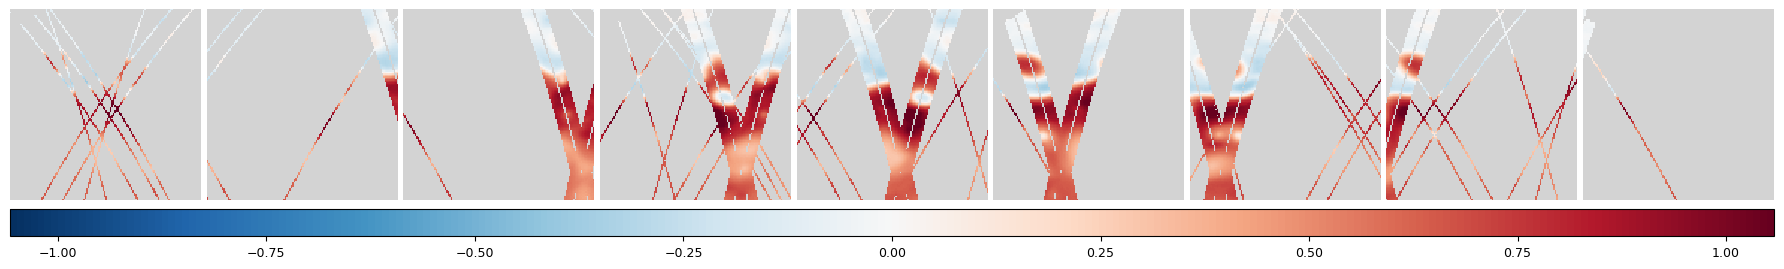

  Saved: figures/FM_ssh_gf/FM_ssh_gf_gt.png


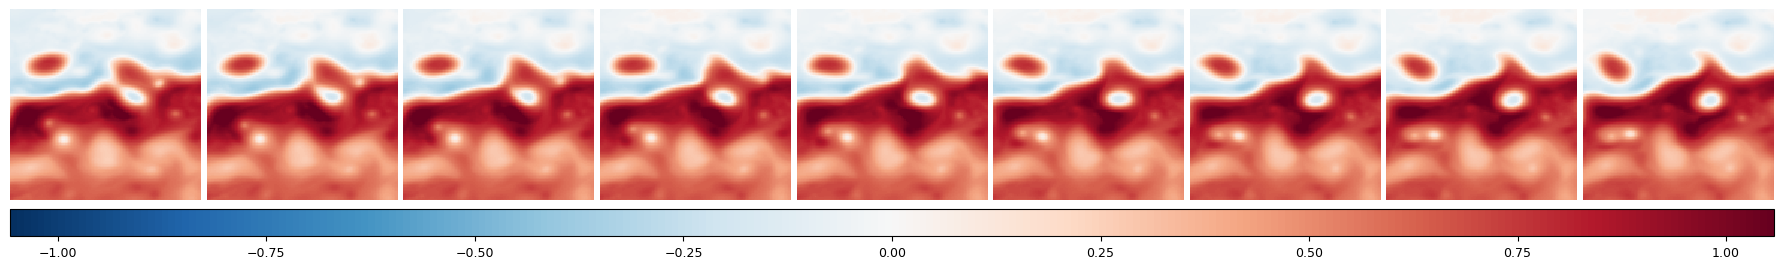

  Saved: figures/FM_ssh_gf/FM_ssh_gf_fm_mean.png


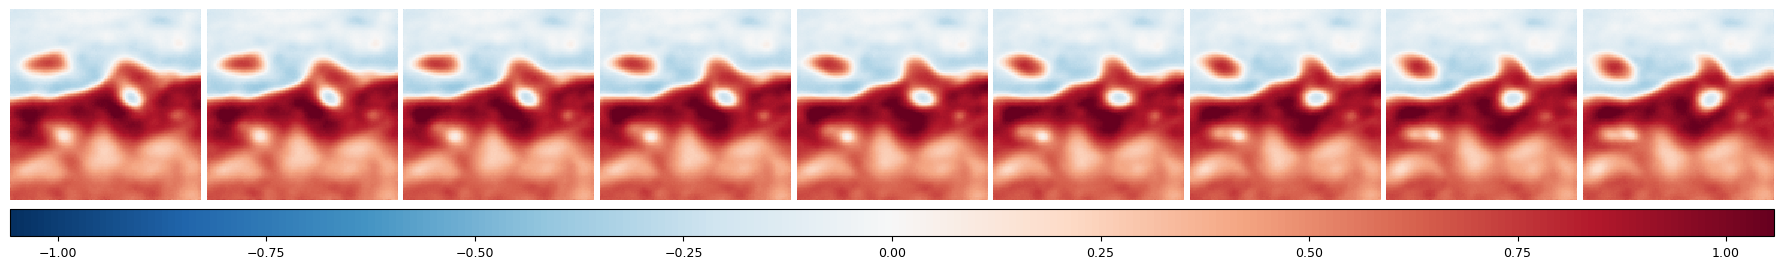

  Saved: figures/FM_ssh_gf/FM_ssh_gf_fm_spread.png


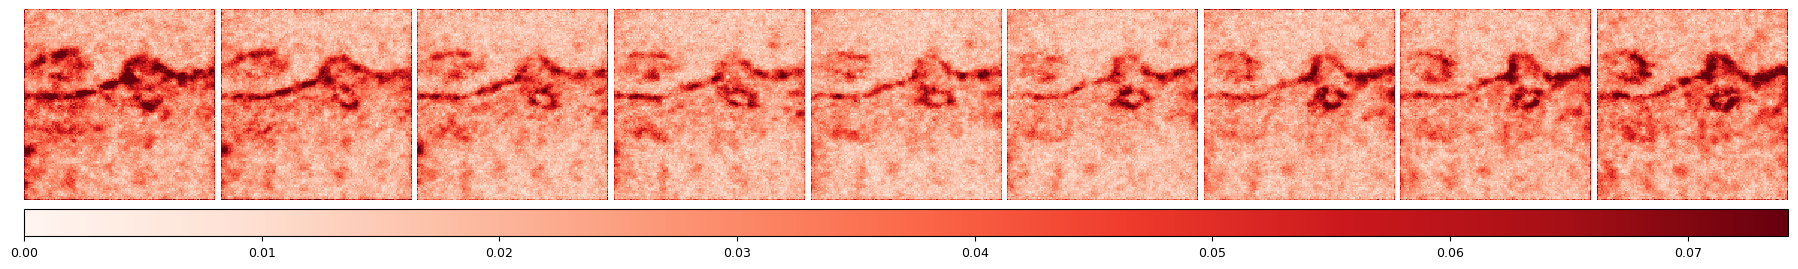

  Saved: figures/FM_ssh_gf/FM_ssh_gf_member0.png


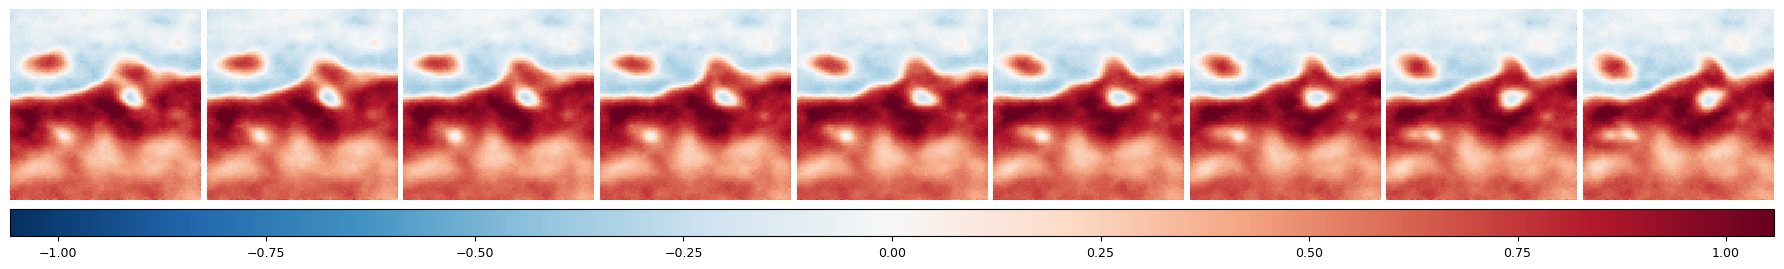

  Saved: figures/FM_ssh_gf/FM_ssh_gf_member1.png


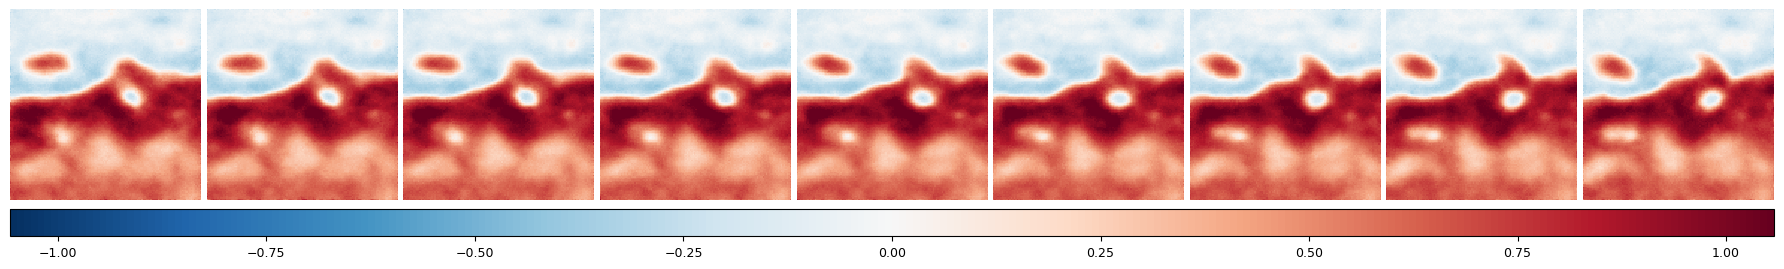

In [ ]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'FM_ssh_gf'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm
mean_phys = ens_mean_1.float().cpu().numpy() * s_norm + m_norm
std_phys  = ens_std_1.float().cpu().numpy()  * s_norm
mbr0_phys = ensemble_1[0].float().cpu().numpy() * s_norm + m_norm
mbr1_phys = ensemble_1[1].float().cpu().numpy() * s_norm + m_norm

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C, left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

for data, fname, vmin, vmax, cmap in [
    (obs_phys,  f'{FIG_TAG}_obs',        vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',         vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_fm_mean',    vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_fm_spread',  0.0,    vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0',    vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1',    vmin_f, vmax_f, cmap_f),
]:
    _save_strip(data, fname, vmin, vmax, cmap)

### ODE Transport Process — Heun trajectory

  Saved: figures/FM_ssh_gf/FM_ssh_gf_transport.png


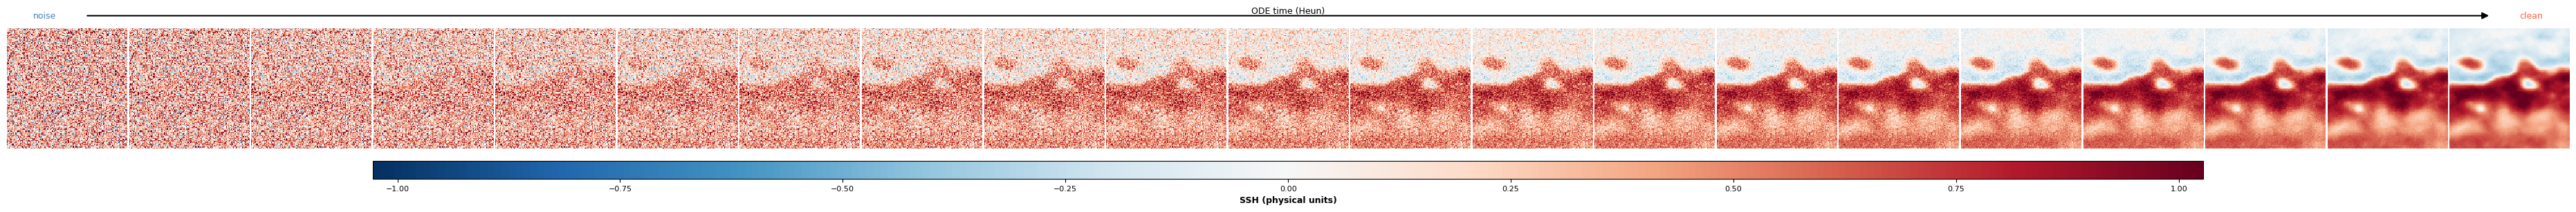

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = C // 2
N_SHOW = 10

N_VIZ_STEPS = 20
torch.manual_seed(42)
noise_traj = torch.randn(1, C, H, W, device=device, dtype=dtype)
y_traj     = y_obs[0:1]

with torch.no_grad():
    _, trajectory = heun_sample(ema_unet, noise_traj, y_traj, n_steps=N_VIZ_STEPS)

transport_n = torch.stack(trajectory, dim=0)[:, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

FW, FH   = 2.4, 2.4
ARR_H    = 0.28
GAP_1    = 0.14
CB_H     = 0.26
GAP_2    = 0.16

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

arr_y_f   = (ARR_H / 2) / fig_h
cb_bot_f  = (ARR_H + GAP_1) / fig_h
cb_h_f    = CB_H / fig_h
img_bot_f = (ARR_H + GAP_1 + CB_H + GAP_2) / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))

gs = GridSpec(1, nf, left=0.01, right=0.99,
              top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

vmax_t = float(np.nanpercentile(np.abs(transport_p), 99))
cmap_t = plt.cm.RdBu_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=-vmax_t, vmax=vmax_t, interpolation='nearest')
    ax.axis('off')

cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(-vmax_t, vmax_t))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('SSH (physical units)', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'ODE time (Heun)', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()